# Phân cụm dữ liệu bằng giải thuật K-means (unsupervised learning)

## Mục tiêu 
- Hiểu hoạt động của giải thuật K-means 
- Biết cách sử dụng K-means: thay đổi tham số, đánh giá chất lượng
- Ứng dụng 

## Dữ liệu 
- Sử dụng hàm sinh dữ liệu tự động của sklearn (sinh ra các điểm ngẫu nhiên theo phân phối Gauss)
- Mỗi dữ liệu là một điểm trên mặt phẳng Oxy
- Ảnh bird_small.png: hình ảnh về một chú chim, được sử dụng để minh họa tác dụng của K-means trong việc nén ảnh

## Yêu cầu
- Sử dụng K-means để phân loại các điểm dữ liệu. 
- Thử nghiệm các trường hợp có số cụm nhiều hơn hoặc ít hơn 

# Các thư viện sử dụng 

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


# Chuẩn bị dữ liệu 
- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương đương 100 điểm 
    - random_state: biến cố định hàm random - để các điểm sinh ngẫu nhiên 
    
- Mỗi điểm dữ liệu có 2 chiều 

In [4]:
n_samples = 100
random_state = 170
center_points = [[1, 1], [-1, -1], [1, -1]] 

X, y = make_blobs(n_samples=n_samples, random_state=random_state, centers=center_points, cluster_std=0.6)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:5])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]]


**Vẽ các điểm ảnh sử dụng matlib plot**

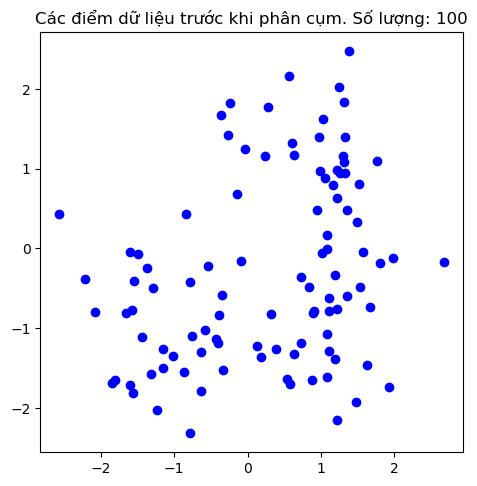

In [5]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()

#  Dựng giải thuật K-means và huấn luyện
- Sử dụng thư viện sklearn để xây dựng giải thuật K-means, xem chi tiết tại [tài liệu hướng dẫn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

In [6]:
k_cluster = 3
k_mean_model = KMeans(n_clusters=k_cluster, random_state=random_state)
k_mean_model.fit(X)

centers = np.array(k_mean_model.cluster_centers_) # cluster_centers_: là thuộc tính lưu trữ các 
                                                  # tâm cụm sau khi training 
print("Tâm cụm sau khi training ({} tâm): \n".format(k_cluster),
      centers)


Tâm cụm sau khi training (3 tâm): 
 [[ 1.11177838 -0.94555162]
 [ 0.88823619  1.19442485]
 [-1.13949326 -0.97100768]]


c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# Kiểm tra giải thuật K-means 

- Kiểm tra các điểm dữ liệu thuộc vào cụm nào 
- Vẽ biểu đồ hiển thị, trong đó các điểm thuộc các cụm khác nhau sẽ có các màu khác nhau 

Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: 

[1 2 1 1 2]


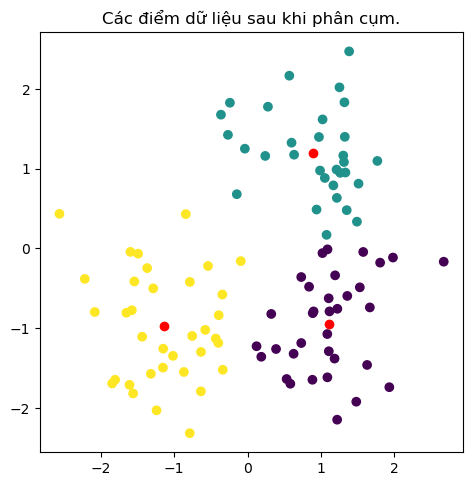

In [8]:
y_pred = k_mean_model.predict(X)
print("Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: \n")
print(y_pred[:5])

plt.figure(figsize=(12, 12))
plt.subplot(222)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.scatter(centers[:, 0], centers[:, 1], c='red')
plt.title("Các điểm dữ liệu sau khi phân cụm.")
plt.show()

# Bài tập 1
Yêu cầu: Thử nghiệm trường hợp dữ liệu sinh ra chỉ có 2 cụm nhưng huấn luyện K-means với các tham số k = 3,4,5 cụm

- Tự viết code sinh dữ liệu tương tự bên trên
- Xây dựng mô hình 3,4,5 cụm

Gợi ý: thay đổi tham số số cụm khi dựng giải thuật K-means

Kết quả phải ra được hình ảnh thể hiện đúng số tâm cụm và phân bố cụm. 

In [13]:
#Sinh các điểm dữ liệu
x, y = make_blobs(n_samples=100, random_state=170, centers=2)
print(f"Số chiều điểm dữ liệu: {x.shape}")
print(f"5 điểm dữ liệu đầu tiên: \n {x[:5]}")

Số chiều điểm dữ liệu: (100, 2)
5 điểm dữ liệu đầu tiên: 
 [[ -8.82010859  -6.84538977]
 [ -6.40925693   1.4906577 ]
 [ -4.41103739  -0.39438685]
 [-10.21171254  -5.1951081 ]
 [ -8.6654155   -5.81125295]]


c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\tonyb\miniconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


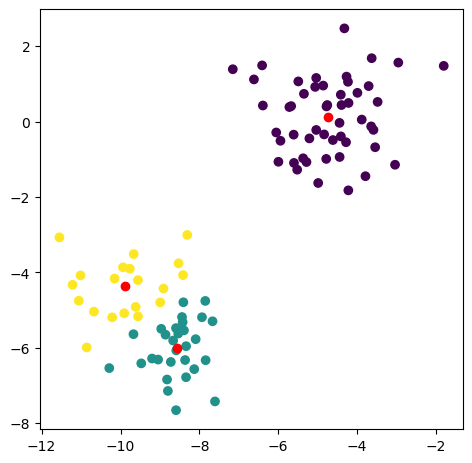

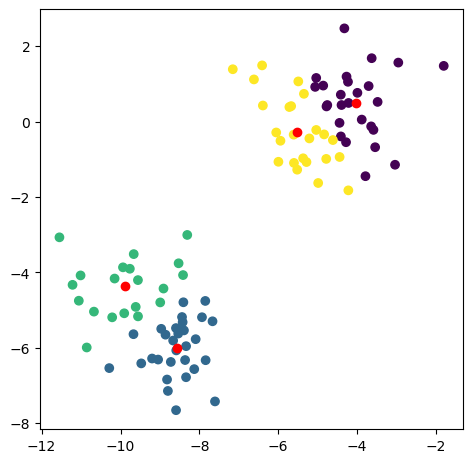

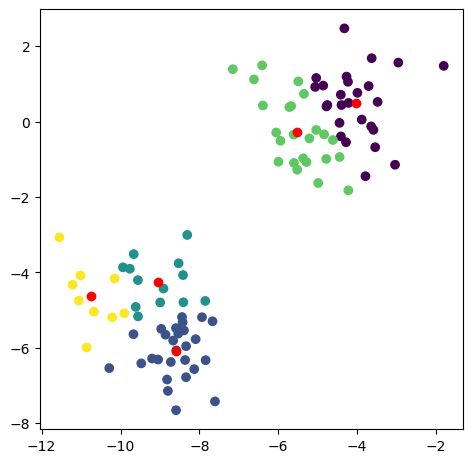

In [17]:
for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=170)
    kmeans.fit(x)
    y_pred = kmeans.predict(x)
    centroids = kmeans.cluster_centers_
    plt.figure(figsize=(12, 12))
    plt.subplot(222)
    plt.scatter(x[:,0], x[:,1], c=y_pred)
    plt.scatter(centroids[:,0], centroids[:,1], c='red')

# Ứng dụng nén ảnh 

- Đặt vấn đề:
    - Muốn xây dựng 1 hệ thống nén dữ liệu hình ảnh 
    - Có thể tuỳ chỉnh được độ sắc nét, giảm kích thước bộ nhớ, nhưng không làm sai lệch quá nhiều dưới mắt nhìn.  
- Giải pháp
    - Sử dụng giải thuật K-means, tự động phân cụm các điểm ảnh, giới hạn số lượng màu để giảm kích thước ảnh 
    - Mỗi điểm ảnh sẽ được quy về 1 cụm nào đó, mang giá trị màu bằng màu của tâm cụm. 


## Thư viện sử dụng - hỗ trợ hình ảnh 

In [2]:
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from IPython.display import Image, display

## Đọc dữ liệu hình ảnh
- Mỗi điểm ảnh là 1 mẫu quan sát 
- Phân cụm tập dữ liệu (tập các điểm ảnh) về k nhãn

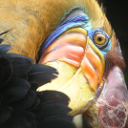

Dữ liệu ảnh trước khi reshape: (128, 128, 3)
Số chiều của dữ liệu hình ảnh:  (16384, 3)
Tổng số điểm ảnh là:  16384
Mỗi điểm ảnh có số chiều =  3


In [18]:
path_img = 'bird_small.png'

display(Image(path_img, width=250, unconfined=True))

img = io.imread(path_img)
print("Dữ liệu ảnh trước khi reshape:", img.shape)

img_shape = img.shape # 128x128x3
data_img = (img / 255.0).reshape(-1,img.shape[2]) # chuyển ma trận 128x128x3 về mảng 2 chiều, giữ lại chiều .shape[2]                    

print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

## Xây dựng mô hình kmean để nén ảnh 
- Số lượng cụm chính là số lượng màu ta giữ lại 
- Số lượng cụm càng nhỏ thì kích thước ảnh cho ra càng nhỏ 

In [35]:
n_color = 10
k_mean_model = KMeans(n_clusters=n_color)

**Huấn luyện mô hình**  

In [36]:
k_mean_model.fit(data_img)

KMeans(n_clusters=10)

In [37]:
# Hiển thị một số thông tin đã học của mô hình 
print("Số chiều của tâm cụm: ", k_mean_model.cluster_centers_.shape)
print(k_mean_model.cluster_centers_)
print(k_mean_model.labels_[0:20])

Số chiều của tâm cụm:  (10, 3)
[[0.86704875 0.70003897 0.42911047]
 [0.10010922 0.10693176 0.09714503]
 [0.69956552 0.61706187 0.53689898]
 [0.49920441 0.45035708 0.44975255]
 [0.50088727 0.37179228 0.22098641]
 [0.91754334 0.80950819 0.65679407]
 [0.97092091 0.93982738 0.80703675]
 [0.54907148 0.67244527 0.82363316]
 [0.25972582 0.23672099 0.23012054]
 [0.75091217 0.54306145 0.26211088]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Sinh dữ liệu ảnh mới 

In [39]:
# k_mean_model.labels_: chứa nhãn của tất cả các điểm ảnh 
# k_mean_model.cluster_centers_: chứa các tâm cụm. 
#new_arr = arr1[index]
img128=k_mean_model.cluster_centers_[k_mean_model.labels_]

print(img128.shape)

# chuẩn hoá lại kích thước ảnh theo chiều dài, rộng ban đầu 
img128=np.reshape(img128, img_shape)
print(img128.shape)
image.imsave('img128.png', img128)

(16384, 3)
(128, 128, 3)


In [40]:
# hiển thị kích thước hình ảnh trước và sau khi nén 
import os
print('Size of compressed image: ' + str(os.path.getsize('img128.png')) + ' KB')
print('Size of original image: ' + str(os.path.getsize('bird_small.png')) + ' KB')

Size of compressed image: 7207 KB
Size of original image: 33031 KB


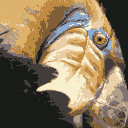

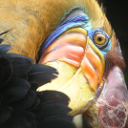

In [41]:
from IPython.core.display import Image, display

#Save image
display(Image('img128.png', width=250, unconfined=True))
display(Image(path_img, width=250, unconfined=True))

# Bài tập 2
Yêu cầu: Nén ảnh trên thành ảnh có số màu < 5 và kiểm tra 

Gợi ý: thay đổi tham số "số cụm" khi xây dựng K-means 

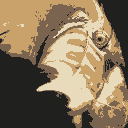

In [19]:
kmeans =KMeans(n_clusters=4, random_state=170)
kmeans.fit(data_img)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
img128 = centers[labels].reshape(img.shape)
image.imsave('img128.png', img128)
display(Image('img128.png', width=250, unconfined=True))